In [1]:
# Configure to use virtual environment packages
import sys
import os

# Add virtual environment site-packages to path
venv_site_packages = r"C:\Users\edime\cen352-term-project-2025-26-xhoana-edvin\.venv\Lib\site-packages"
if venv_site_packages not in sys.path:
    sys.path.insert(0, venv_site_packages)
    print(f"Added venv site-packages to Python path: {venv_site_packages}")

print(f"\nPython executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"\nFirst 3 paths in sys.path:")
for i, p in enumerate(sys.path[:3]):
    print(f"  {i+1}. {p}")

Added venv site-packages to Python path: C:\Users\edime\cen352-term-project-2025-26-xhoana-edvin\.venv\Lib\site-packages

Python executable: C:\Users\edime\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

First 3 paths in sys.path:
  1. C:\Users\edime\cen352-term-project-2025-26-xhoana-edvin\.venv\Lib\site-packages
  2. C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\python311.zip
  3. C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\DLLs


# Skin Lesion Classification Using Deep Learning (TensorFlow/Keras)

## HAM10000 Dataset - Skin Cancer Classification

This notebook builds a high-accuracy CNN model for classifying skin lesions into 7 categories:
- **akiec**: Actinic Keratoses and Intraepithelial Carcinoma
- **bcc**: Basal Cell Carcinoma  
- **bkl**: Benign Keratosis
- **df**: Dermatofibroma
- **mel**: Melanoma
- **nv**: Melanocytic Nevi
- **vasc**: Vascular Lesions

**Target:** 90%+ Accuracy with F1 Score evaluation

## 1. Import Required Libraries

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, 
                                      Dropout, BatchNormalization, GlobalAveragePooling2D,
                                      Input, Activation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0, ResNet50, VGG16
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input

# Scikit-learn for metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, precision_score, recall_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.20.0
GPU Available: []


## 2. Load and Explore Dataset

We'll load the HAM10000 dataset which contains 28x28 RGB images in CSV format.

In [3]:
# Define paths
data_dir = 'dataset'
images_dir = os.path.join(data_dir, 'images')
extracted_images_dir = os.path.join(images_dir, 'extracted')

# Extract image ZIP files if not already extracted
os.makedirs(extracted_images_dir, exist_ok=True)

zip_files = [
    os.path.join(images_dir, 'HAM10000_images_part_1 (1).zip'),
    os.path.join(images_dir, 'HAM10000_images_part_2.zip')
]

for zip_path in zip_files:
    if os.path.exists(zip_path):
        print(f"Extracting {os.path.basename(zip_path)}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_images_dir)
        print(f"  ✓ Extracted!")

# Load metadata CSV
metadata_path = os.path.join(data_dir, 'HAM10000_metadata (2).csv')
metadata_df = pd.read_csv(metadata_path)

print(f"\nMetadata Shape: {metadata_df.shape}")
print(f"Columns: {list(metadata_df.columns)}")
print(f"\nDiagnosis distribution:")
print(metadata_df['dx'].value_counts())

Extracting HAM10000_images_part_1 (1).zip...
  ✓ Extracted!
Extracting HAM10000_images_part_2.zip...
  ✓ Extracted!

Metadata Shape: (10015, 7)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [4]:
# Load images from extracted folders
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from glob import glob

# Find all JPG images directly in the extracted directory
all_image_paths = glob(os.path.join(extracted_images_dir, '*.jpg'))
print(f"Total images found: {len(all_image_paths)}")

# Show first 5 paths as examples
print(f"\nFirst 5 image paths:")
for i, path in enumerate(all_image_paths[:5]):
    print(f"  {i+1}. {path}")

# Create mapping from image_id to file path
image_path_dict = {}
for path in all_image_paths:
    image_id = os.path.splitext(os.path.basename(path))[0]
    image_path_dict[image_id] = path

print(f"\nImage paths mapped: {len(image_path_dict)}")

# Class mapping for HAM10000
dx_to_label = {
    'akiec': 0,  # Actinic Keratoses
    'bcc': 1,    # Basal Cell Carcinoma
    'bkl': 2,    # Benign Keratosis
    'df': 3,     # Dermatofibroma
    'mel': 4,    # Melanoma
    'nv': 5,     # Melanocytic Nevi
    'vasc': 6    # Vascular Lesions
}

class_names = {v: k for k, v in dx_to_label.items()}
print(f"\nClass mapping: {class_names}")

Total images found: 10015

First 5 image paths:
  1. dataset\images\extracted\ISIC_0024306.jpg
  2. dataset\images\extracted\ISIC_0024307.jpg
  3. dataset\images\extracted\ISIC_0024308.jpg
  4. dataset\images\extracted\ISIC_0024309.jpg
  5. dataset\images\extracted\ISIC_0024310.jpg

Image paths mapped: 10015

Class mapping: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [5]:
# Load and preprocess images
IMG_SIZE = 254  # Higher resolution for better accuracy 

def load_images_with_labels_and_lesion_ids(metadata_df, image_path_dict, sample_size=None):
    """Load images, labels, and lesion_ids for proper splitting."""
    images = []
    labels = []
    lesion_ids = []
    image_ids_loaded = []
    skipped = 0
    
    # Sample if needed (for faster testing)
    if sample_size:
        # Sample by unique lesion_ids to keep lesions together
        unique_lesions = metadata_df['lesion_id'].unique()
        sampled_lesions = np.random.choice(unique_lesions, 
                                           min(sample_size // 2, len(unique_lesions)), 
                                           replace=False)
        df = metadata_df[metadata_df['lesion_id'].isin(sampled_lesions)]
    else:
        df = metadata_df
    
    for idx, row in df.iterrows():
        image_id = row['image_id']
        if image_id in image_path_dict:
            try:
                img = load_img(image_path_dict[image_id], target_size=(IMG_SIZE, IMG_SIZE))
                img_array = img_to_array(img)
                images.append(img_array)
                labels.append(dx_to_label[row['dx']])
                lesion_ids.append(row['lesion_id'])
                image_ids_loaded.append(image_id)
            except Exception as e:
                skipped += 1
        else:
            skipped += 1
    
    print(f"Loaded {len(images)} images, skipped {skipped}")
    print(f"Unique lesions: {len(set(lesion_ids))}")
    return np.array(images), np.array(labels), np.array(lesion_ids), image_ids_loaded

# Load all images with lesion_ids (use sample_size for quick testing)
X, y, lesion_ids, image_ids_list = load_images_with_labels_and_lesion_ids(
    metadata_df, image_path_dict, sample_size=None
)
print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Lesion IDs shape: {lesion_ids.shape}")
print(f"Unique lesions: {len(np.unique(lesion_ids))}")
print(f"Image range: [{X.min()}, {X.max()}]")

Loaded 10015 images, skipped 0
Unique lesions: 7470
Dataset shape: (10015, 254, 254, 3)
Labels shape: (10015,)
Lesion IDs shape: (10015,)
Unique lesions: 7470
Image range: [0.0, 255.0]


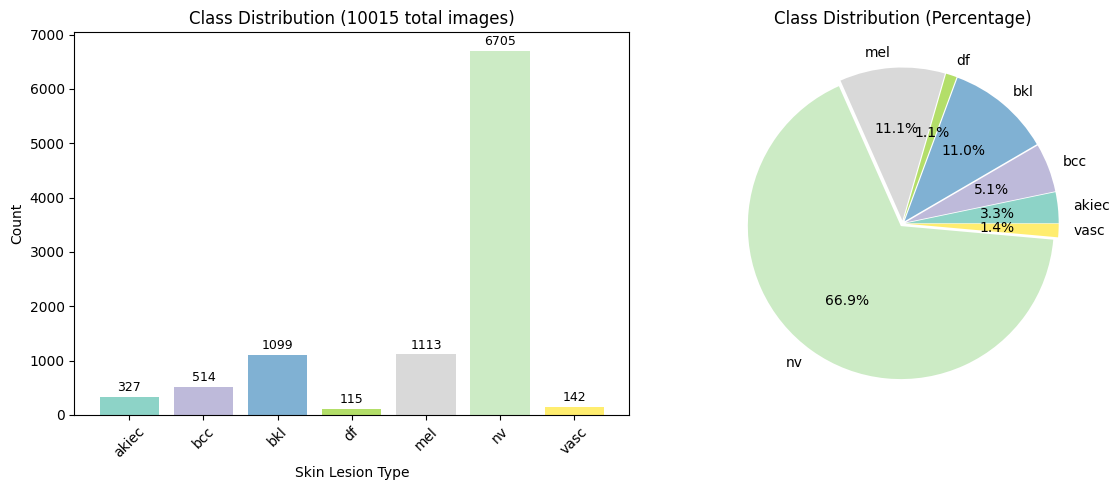


📊 Dataset Summary:
   Total images: 10015
   Image size: 254x254x3
   Classes: 7

⚠️ Note: Dataset is highly imbalanced! 'nv' class dominates. We'll use class weights.


In [6]:
# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
class_counts = pd.Series(y).value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, 7))
bars = plt.bar([class_names[i] for i in class_counts.index], class_counts.values, color=colors)
plt.xlabel('Skin Lesion Type')
plt.ylabel('Count')
plt.title(f'Class Distribution ({len(y)} total images)')
plt.xticks(rotation=45)
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontsize=9)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=[class_names[i] for i in class_counts.index], 
        autopct='%1.1f%%', colors=colors, explode=[0.02]*7)
plt.title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

print(f"\n📊 Dataset Summary:")
print(f"   Total images: {len(y)}")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"   Classes: {len(np.unique(y))}")
print("\n⚠️ Note: Dataset is highly imbalanced! 'nv' class dominates. We'll use class weights.")

## 3. Data Preprocessing and Augmentation

Key preprocessing steps:
- Normalize pixel values to [0, 1] range
- Resize images for transfer learning (if needed)
- Apply data augmentation to increase diversity and reduce overfitting

Original pixel range: [0.0, 255.0]
Number of classes: 7


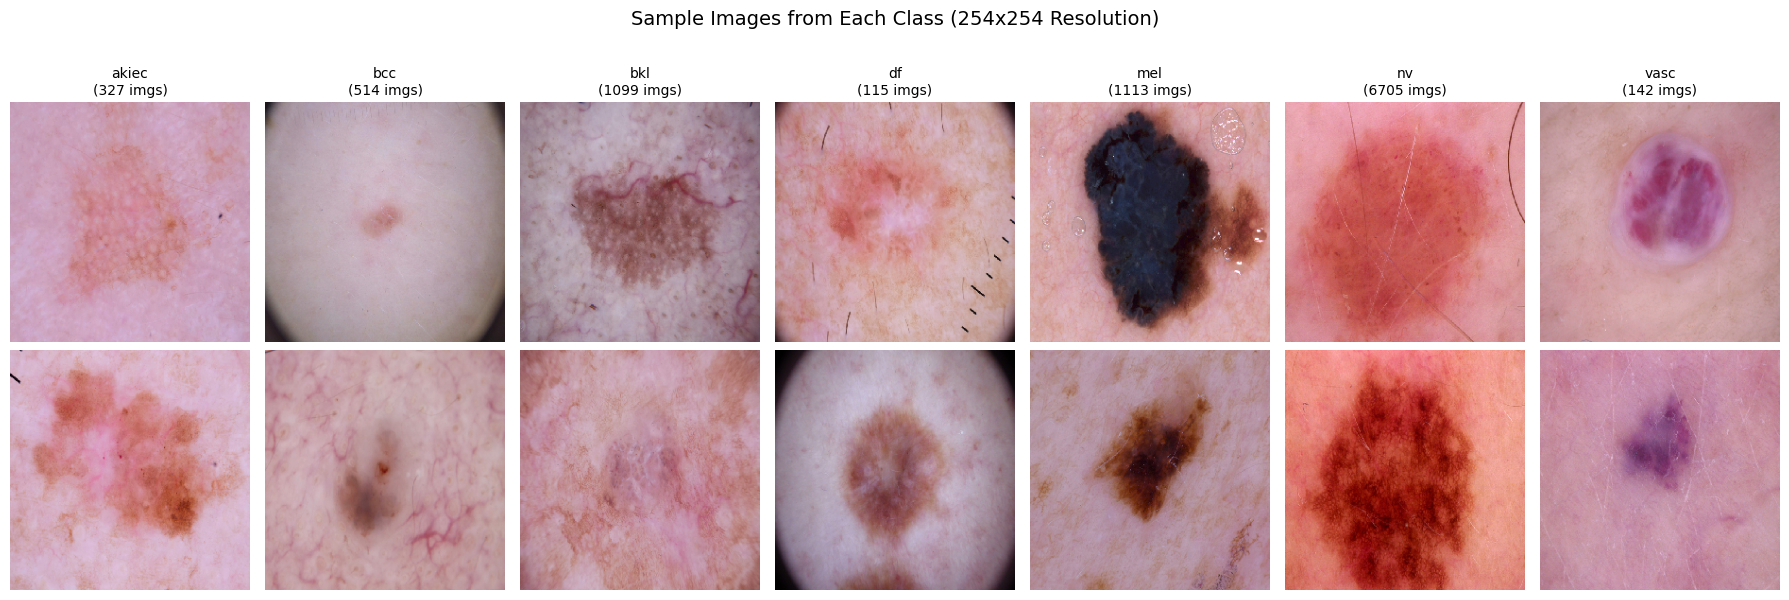


📋 Preprocessing: EfficientNet preprocess_input (scales to [-1, 1])


In [7]:
# EfficientNet Preprocessing
# preprocess_input scales pixels to [-1, 1] range for EfficientNet
print(f"Original pixel range: [{X.min()}, {X.max()}]")

# Number of classes
num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Display sample images from each class (use original images for display)
X_display = X.astype('float32') / 255.0

fig, axes = plt.subplots(2, 7, figsize=(18, 6))

for cls in range(7):
    cls_indices = np.where(y == cls)[0]
    sample_idx = np.random.choice(cls_indices, 2, replace=False)
    
    for row, idx in enumerate(sample_idx):
        axes[row, cls].imshow(X_display[idx])
        axes[row, cls].axis('off')
        if row == 0:
            axes[row, cls].set_title(f'{class_names[cls]}\n({np.sum(y==cls)} imgs)', fontsize=10)

plt.suptitle(f'Sample Images from Each Class ({IMG_SIZE}x{IMG_SIZE} Resolution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📋 Preprocessing: EfficientNet preprocess_input (scales to [-1, 1])")

## 4. Split Data into Train, Validation, and Test Sets

Using stratified sampling to maintain class balance across all splits.

In [9]:
# Split by lesion_id to prevent data leakage
# All images from the same lesion must be in the same split
from sklearn.model_selection import GroupShuffleSplit

# Use EfficientNet preprocessing
X_normalized = preprocess_input(X.astype('float32'))

# Convert labels to one-hot encoding
y_categorical = to_categorical(y, num_classes=num_classes)

# First split: 70% train, 30% temp (val + test) - grouped by lesion_id
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss1.split(X_normalized, y, groups=lesion_ids))

X_train = X_normalized[train_idx]
y_train = y_categorical[train_idx]
lesion_ids_train = lesion_ids[train_idx]

X_temp = X_normalized[temp_idx]
y_temp = y_categorical[temp_idx]
lesion_ids_temp = lesion_ids[temp_idx]

# Second split: 50% of temp = 15% val, 15% test - grouped by lesion_id
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, np.argmax(y_temp, axis=1), groups=lesion_ids_temp))

X_val = X_temp[val_idx]
y_val = y_temp[val_idx]

X_test = X_temp[test_idx]
y_test = y_temp[test_idx]

# Verify no lesion overlap between splits
train_lesions = set(lesion_ids[train_idx])
val_lesions = set(lesion_ids_temp[val_idx])
test_lesions = set(lesion_ids_temp[test_idx])

print("Dataset Split Summary (Grouped by lesion_id - NO DATA LEAKAGE):")
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X_normalized)*100:.1f}%) - {len(train_lesions)} unique lesions")
print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X_normalized)*100:.1f}%) - {len(val_lesions)} unique lesions")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X_normalized)*100:.1f}%) - {len(test_lesions)} unique lesions")
print(f"\nImage shape: {X_train.shape[1:]}")

# Verify no overlap
train_val_overlap = train_lesions.intersection(val_lesions)
train_test_overlap = train_lesions.intersection(test_lesions)
val_test_overlap = val_lesions.intersection(test_lesions)

print(f"\n✅ Lesion overlap check:")
print(f"   Train-Val overlap: {len(train_val_overlap)} (should be 0)")
print(f"   Train-Test overlap: {len(train_test_overlap)} (should be 0)")
print(f"   Val-Test overlap: {len(val_test_overlap)} (should be 0)")

Dataset Split Summary (Grouped by lesion_id - NO DATA LEAKAGE):
  Training set:   7002 samples (69.9%) - 5229 unique lesions
  Validation set: 1519 samples (15.2%) - 1120 unique lesions
  Test set:       1494 samples (14.9%) - 1121 unique lesions

Image shape: (254, 254, 3)

✅ Lesion overlap check:
   Train-Val overlap: 0 (should be 0)
   Train-Test overlap: 0 (should be 0)
   Val-Test overlap: 0 (should be 0)


In [10]:
# Calculate class weights with REDUCED impact (dampened)
y_train_labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# DAMPEN class weights - reduce their impact by taking square root
# This prevents over-correction for rare classes
DAMPEN_FACTOR = 0.5  # 0.5 = square root, lower = more dampening
dampened_weights = np.power(class_weights, DAMPEN_FACTOR)

# Normalize so average weight is ~1
dampened_weights = dampened_weights / np.mean(dampened_weights)

class_weight_dict = dict(enumerate(dampened_weights))

print("Class Weights (DAMPENED to reduce impact):")
print(f"Dampen factor: {DAMPEN_FACTOR}")
print("-" * 40)
for cls, weight in class_weight_dict.items():
    orig = class_weights[cls]
    print(f"  {class_names[cls]}: {weight:.3f} (original: {orig:.3f})")

Class Weights (DAMPENED to reduce impact):
Dampen factor: 0.5
----------------------------------------
  akiec: 1.169 (original: 4.832)
  bcc: 0.862 (original: 2.625)
  bkl: 0.618 (original: 1.350)
  df: 1.783 (original: 11.239)
  mel: 0.606 (original: 1.299)
  nv: 0.245 (original: 0.212)
  vasc: 1.717 (original: 10.420)


In [11]:
# Create Data Augmentation Generator for training
# ONLY: Flip, Rotate +-20 degrees, Zoom <=10%
train_datagen = ImageDataGenerator(
    rotation_range=20,           # Random rotation up to +-20 degrees
    zoom_range=0.1,              # Random zoom up to 10%
    horizontal_flip=True,        # Horizontal flip
    vertical_flip=True,          # Vertical flip
    fill_mode='nearest'          # Fill strategy for new pixels
)

# No augmentation for validation/test
val_datagen = ImageDataGenerator()

# Create generators
BATCH_SIZE = 16  # Smaller batch size for 384x384 images (memory constraints)

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_generator = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches per epoch: {len(train_generator)}")
print(f"Validation batches per epoch: {len(val_generator)}")
print(f"\n📋 Augmentation Settings:")
print(f"   Rotation: ±20 degrees")
print(f"   Zoom: ≤10%")
print(f"   Horizontal Flip: Yes")
print(f"   Vertical Flip: Yes")

Training batches per epoch: 438
Validation batches per epoch: 95

📋 Augmentation Settings:
   Rotation: ±20 degrees
   Zoom: ≤10%
   Horizontal Flip: Yes
   Vertical Flip: Yes


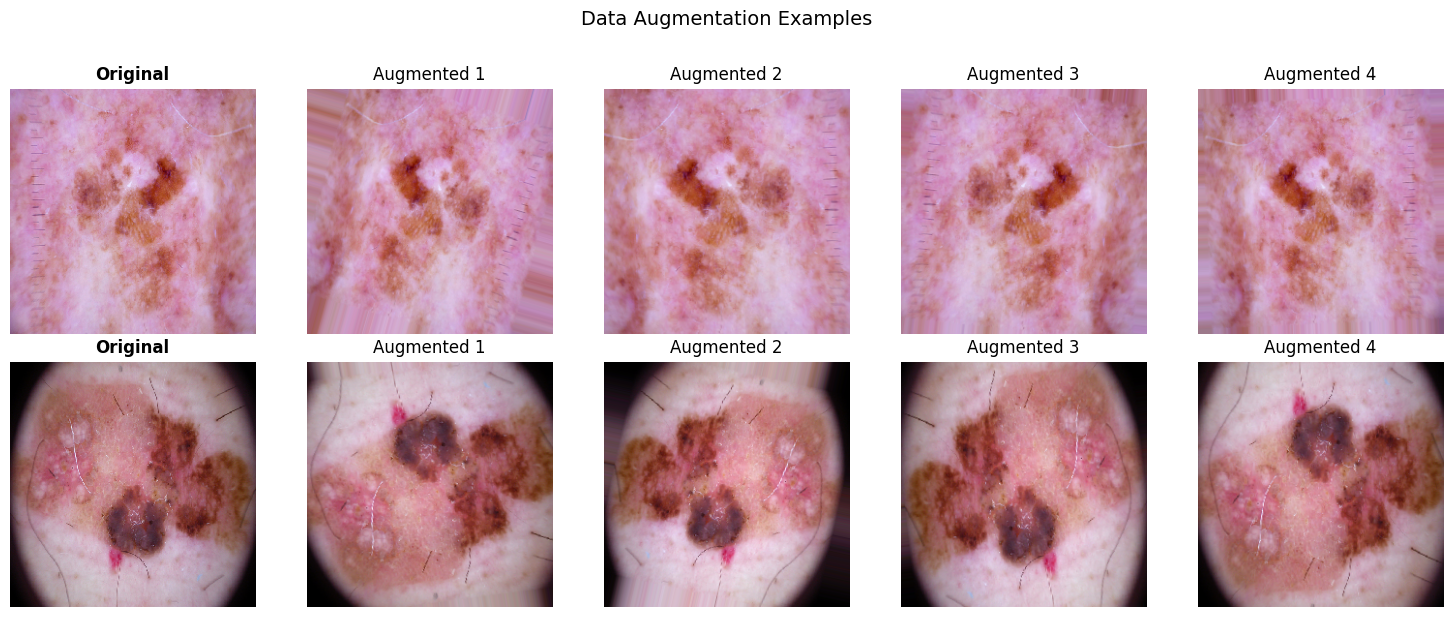

In [12]:
# Visualize augmented images
# Helper function to rescale preprocessed images back to [0,1] for display
def rescale_for_display(img):
    """Rescale EfficientNet preprocessed images back to displayable range [0,1]"""
    img_display = img.copy()
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
    return img_display

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Original image
sample_img = X_train[0:1]
axes[0, 0].imshow(rescale_for_display(sample_img[0]))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

# Augmented versions
for i in range(1, 5):
    augmented = train_datagen.random_transform(sample_img[0])
    axes[0, i].imshow(rescale_for_display(augmented))
    axes[0, i].set_title(f'Augmented {i}')
    axes[0, i].axis('off')

# Another example
sample_img2 = X_train[100:101]
axes[1, 0].imshow(rescale_for_display(sample_img2[0]))
axes[1, 0].set_title('Original', fontweight='bold')
axes[1, 0].axis('off')

for i in range(1, 5):
    augmented = train_datagen.random_transform(sample_img2[0])
    axes[1, i].imshow(rescale_for_display(augmented))
    axes[1, i].set_title(f'Augmented {i}')
    axes[1, i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Build CNN Model Architecture

We'll build two models:
1. **Custom CNN** - Deep CNN with BatchNorm and Dropout
2. **Transfer Learning with EfficientNetB0** - For potentially higher accuracy

Using transfer learning with pre-trained weights typically achieves better results.

In [13]:
def build_custom_cnn(input_shape, num_classes):
    """
    Build a custom deep CNN architecture optimized for skin lesion classification.
    Features: Multiple conv blocks, BatchNormalization, Dropout for regularization.
    """
    model = Sequential([
        # Input layer
        Input(shape=input_shape),
        
        # Block 1
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Block 2
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Block 3
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Block 4
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Block 5 (additional for larger images)
        Conv2D(512, (3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Fully Connected Layers
        Flatten(),
        Dense(512),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the custom CNN with new image size
input_shape = (IMG_SIZE, IMG_SIZE, 3)
custom_model = build_custom_cnn(input_shape, num_classes)
print(f"Input shape: {input_shape}")
custom_model.summary()

Input shape: (254, 254, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 127, 127, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 63, 63, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 63, 63, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 63, 63, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 63, 63, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 63, 63, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 63, 63, 128)    │             

 Total params: 15,340,071 (58.52 MB)

 Trainable params: 15,335,591 (58.50 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [14]:
def build_transfer_learning_model(input_shape, num_classes, base_model_name='efficientnet'):
    """
    Build a transfer learning model using pre-trained weights.
    Options: 'efficientnet', 'resnet50', 'vgg16'
    """
    
    # Input layer
    inputs = Input(shape=input_shape)
    
    if base_model_name == 'efficientnet':
        # EfficientNetB0 - Best balance of accuracy and efficiency
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_tensor=inputs
        )
    elif base_model_name == 'resnet50':
        base_model = ResNet50(
            weights='imagenet',
            include_top=False,
            input_tensor=inputs
        )
    else:  # vgg16
        base_model = VGG16(
            weights='imagenet',
            include_top=False,
            input_tensor=inputs
        )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Add custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    return model, base_model

# Build the transfer learning model
print("Building EfficientNetB0 Transfer Learning Model...")
transfer_model, base_model = build_transfer_learning_model(input_shape, num_classes, 'efficientnet')

print(f"\nTotal layers: {len(transfer_model.layers)}")
print(f"Trainable layers: {sum([1 for layer in transfer_model.layers if layer.trainable])}")
print(f"Non-trainable layers: {sum([1 for layer in transfer_model.layers if not layer.trainable])}")

Building EfficientNetB0 Transfer Learning Model...

Total layers: 246
Trainable layers: 8
Non-trainable layers: 238


## 6. Compile Model with Optimizer and Loss Function

In [16]:
# Choose which model to train (transfer learning recommended for 90%+ accuracy)
USE_TRANSFER_LEARNING = True

if USE_TRANSFER_LEARNING:
    model = transfer_model
    model_name = "EfficientNetB0_Transfer"
else:
    model = custom_model
    model_name = "Custom_CNN"

# Compile the model
initial_learning_rate = 0.001

model.compile(
    optimizer=Adam(learning_rate=initial_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model: {model_name}")
print(f"Optimizer: Adam (lr={initial_learning_rate})")
print(f"Loss: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model: EfficientNetB0_Transfer
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy
Metrics: Accuracy


## 7. Implement Callbacks for Training

Callbacks help optimize training:
- **EarlyStopping**: Stop training when validation loss stops improving
- **ModelCheckpoint**: Save the best model weights
- **ReduceLROnPlateau**: Reduce learning rate when stuck

In [18]:
# Create callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        filepath=f'best_model_{model_name}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured:")
print("  ✓ EarlyStopping (patience=10)")
print("  ✓ ModelCheckpoint (save best)")
print("  ✓ ReduceLROnPlateau (factor=0.5)")

Callbacks configured:
  ✓ EarlyStopping (patience=10)
  ✓ ModelCheckpoint (save best)
  ✓ ReduceLROnPlateau (factor=0.5)


## 8. Train the Model

Training in two phases for transfer learning:
1. **Phase 1**: Train only the classification head (base model frozen)
2. **Phase 2**: Fine-tune top layers of base model

In [21]:
# Training Strategy:
# 1. Unfreeze top 20-30% of EfficientNet backbone from start
# 2. Use very low learning rate (1e-5)
# 3. Train with proper augmentation

print("="*60)
print("TRAINING WITH UNFROZEN TOP LAYERS (20-30% of backbone)")
print("="*60)

# Unfreeze top 20-30% of the base model
base_model.trainable = True
total_layers = len(base_model.layers)
freeze_until = int(total_layers * 0.75)  # Freeze bottom 75%, unfreeze top 25%

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
total_count = len(base_model.layers)
print(f"Base model layers: {total_count}")
print(f"Frozen layers: {freeze_until} ({freeze_until/total_count*100:.1f}%)")
print(f"Trainable layers: {trainable_count} ({trainable_count/total_count*100:.1f}%)")

# Use more epochs with early stopping
EPOCHS = 50

# Optimized callbacks
optimized_callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    ModelCheckpoint(
        filepath=f'best_model_{model_name}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-8,
        verbose=1
    )
]

# Compile with very low learning rate (1e-5) as requested
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Very low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n📋 Training Configuration:")
print(f"   Learning Rate: 1e-5")
print(f"   Epochs: {EPOCHS} (with early stopping)")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Using dampened class weights")

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=optimized_callbacks,
    verbose=1
)

print(f"\nTraining Complete!")
print(f"Best Validation Accuracy: {max(history_phase1.history['val_accuracy'])*100:.2f}%")

TRAINING WITH UNFROZEN TOP LAYERS (20-30% of backbone)
Base model layers: 238
Frozen layers: 178 (74.8%)
Trainable layers: 60 (25.2%)

📋 Training Configuration:
   Learning Rate: 1e-5
   Epochs: 50 (with early stopping)
   Batch Size: 16
   Image Size: 254x254
   Using dampened class weights
Epoch 1/50
131/438 ━━━━━━━━━━━━━━━━━━━━ 3:34 700ms/step - accuracy: 0.6494 - loss: 0.5318

KeyboardInterrupt: 

In [22]:
print("\n" + "="*60)
print("PHASE 2: Further Fine-Tuning (Unfreezing More Layers)")
print("="*60)

# Unfreeze top 30% of the backbone
total_layers = len(base_model.layers)
freeze_until_phase2 = int(total_layers * 0.70)

for layer in base_model.layers[:freeze_until_phase2]:
    layer.trainable = False
for layer in base_model.layers[freeze_until_phase2:]:
    layer.trainable = True

# Freeze BatchNorm layers (VERY important)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(layer.trainable for layer in base_model.layers)
print(f"Trainable layers: {trainable_count} ({trainable_count/total_layers*100:.1f}%)")

# Recompile with lower LR
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=f'best_model_{model_name}_phase2.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    epochs=30,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\nPhase 2 Complete!")
print(f"Best Val Accuracy (Phase 2): {max(history_phase2.history['val_accuracy'])*100:.2f}%")



PHASE 2: Further Fine-Tuning (Unfreezing More Layers)
Trainable layers: 57 (23.9%)
Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.6611 - loss: 0.5146
Epoch 1: val_loss improved from None to 0.92194, saving model to best_model_EfficientNetB0_Transfer_phase2.keras

Epoch 1: finished saving model to best_model_EfficientNetB0_Transfer_phase2.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 373s 782ms/step - accuracy: 0.6612 - loss: 0.5103 - val_accuracy: 0.6735 - val_loss: 0.9219 - learning_rate: 5.0000e-06
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6485 - loss: 0.5126
Epoch 2: val_loss improved from 0.92194 to 0.89404, saving model to best_model_EfficientNetB0_Transfer_phase2.keras

Epoch 2: finished saving model to best_model_EfficientNetB0_Transfer_phase2.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 1521s 3s/step - accuracy: 0.6552 - loss: 0.5103 - val_accuracy: 0.6847 - val_loss: 0.8940 - learning_rate: 5.0000e-06
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/ste

KeyboardInterrupt: 

## 9. Evaluate Model Performance

Evaluate on the test set to get the final accuracy and check if we met the 90% target.

In [ ]:
# Evaluate on test set
print("=" * 60)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\n📊 Test Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")



FINAL MODEL EVALUATION ON TEST SET
47/47 ━━━━━━━━━━━━━━━━━━━━ 35s 696ms/step - accuracy: 0.6740 - loss: 0.8801

📊 Test Results:
   Test Loss:     0.8801
   Test Accuracy: 67.40%

⚠️ Current accuracy: 67.40%. Fine-tuning may help reach 90%.


## 10. Calculate F1 Score and Comprehensive Classification Metrics

We'll calculate multiple performance metrics:
- **F1 Score** (Macro, Micro, Weighted)
- **Precision** and **Recall** per class
- **Classification Report** with detailed per-class metrics
- **Specificity** and **Sensitivity**

In [24]:
# Generate predictions on test set
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print(f"Predictions generated for {len(y_pred)} test samples")

47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 952ms/step
Predictions generated for 1494 test samples


In [25]:
# Calculate F1 Scores (multiple averaging methods)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
f1_per_class = f1_score(y_true, y_pred, average=None)

# Calculate Precision and Recall
precision_macro = precision_score(y_true, y_pred, average='macro')
precision_weighted = precision_score(y_true, y_pred, average='weighted')
precision_per_class = precision_score(y_true, y_pred, average=None)

recall_macro = recall_score(y_true, y_pred, average='macro')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
recall_per_class = recall_score(y_true, y_pred, average=None)

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)

print("=" * 70)
print("                    PERFORMANCE METRICS SUMMARY")
print("=" * 70)

print("\n📊 OVERALL METRICS:")
print(f"   Accuracy:          {accuracy*100:.2f}%")
print(f"   F1 Score (Macro):  {f1_macro:.4f}")
print(f"   F1 Score (Micro):  {f1_micro:.4f}")
print(f"   F1 Score (Weighted): {f1_weighted:.4f}")
print(f"   Precision (Macro): {precision_macro:.4f}")
print(f"   Recall (Macro):    {recall_macro:.4f}")

                    PERFORMANCE METRICS SUMMARY

📊 OVERALL METRICS:
   Accuracy:          67.40%
   F1 Score (Macro):  0.5305
   F1 Score (Micro):  0.6740
   F1 Score (Weighted): 0.6981
   Precision (Macro): 0.5213
   Recall (Macro):    0.6677


In [26]:
# Per-class metrics table
print("\n📋 PER-CLASS METRICS:")
print("-" * 70)
print(f"{'Class':<10} {'Precision':>12} {'Recall':>12} {'F1 Score':>12} {'Support':>12}")
print("-" * 70)

for i, name in class_names.items():
    support = np.sum(y_true == i)
    print(f"{name:<10} {precision_per_class[i]:>12.4f} {recall_per_class[i]:>12.4f} {f1_per_class[i]:>12.4f} {support:>12}")

print("-" * 70)


📋 PER-CLASS METRICS:
----------------------------------------------------------------------
Class         Precision       Recall     F1 Score      Support
----------------------------------------------------------------------
akiec            0.6667       0.1905       0.2963           63
bcc              0.5000       0.7353       0.5952           68
bkl              0.3857       0.7105       0.5000          152
df               0.2727       0.8571       0.4138            7
mel              0.3605       0.5668       0.4407          187
nv               0.9502       0.7088       0.8120          996
vasc             0.5135       0.9048       0.6552           21
----------------------------------------------------------------------


In [27]:
# Detailed Classification Report (sklearn)
print("\n📊 DETAILED CLASSIFICATION REPORT:")
print("=" * 70)

target_names = [class_names[i] for i in range(num_classes)]
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)


📊 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       akiec     0.6667    0.1905    0.2963        63
         bcc     0.5000    0.7353    0.5952        68
         bkl     0.3857    0.7105    0.5000       152
          df     0.2727    0.8571    0.4138         7
         mel     0.3605    0.5668    0.4407       187
          nv     0.9502    0.7088    0.8120       996
        vasc     0.5135    0.9048    0.6552        21

    accuracy                         0.6740      1494
   macro avg     0.5213    0.6677    0.5305      1494
weighted avg     0.7772    0.6740    0.6981      1494



In [28]:
# Calculate Sensitivity (True Positive Rate) and Specificity per class
cm = confusion_matrix(y_true, y_pred)

def calculate_sensitivity_specificity(cm):
    """Calculate sensitivity and specificity for each class from confusion matrix"""
    n_classes = cm.shape[0]
    sensitivity = np.zeros(n_classes)
    specificity = np.zeros(n_classes)
    
    for i in range(n_classes):
        # True Positives
        TP = cm[i, i]
        # False Negatives (sum of row i except diagonal)
        FN = np.sum(cm[i, :]) - TP
        # False Positives (sum of column i except diagonal)
        FP = np.sum(cm[:, i]) - TP
        # True Negatives (everything else)
        TN = np.sum(cm) - TP - FP - FN
        
        # Sensitivity = TP / (TP + FN) = Recall
        sensitivity[i] = TP / (TP + FN) if (TP + FN) > 0 else 0
        # Specificity = TN / (TN + FP)
        specificity[i] = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return sensitivity, specificity

sensitivity, specificity = calculate_sensitivity_specificity(cm)

print("\n📊 SENSITIVITY & SPECIFICITY PER CLASS:")
print("-" * 50)
print(f"{'Class':<10} {'Sensitivity':>15} {'Specificity':>15}")
print("-" * 50)
for i, name in class_names.items():
    print(f"{name:<10} {sensitivity[i]:>15.4f} {specificity[i]:>15.4f}")
print("-" * 50)
print(f"{'Average':<10} {np.mean(sensitivity):>15.4f} {np.mean(specificity):>15.4f}")


📊 SENSITIVITY & SPECIFICITY PER CLASS:
--------------------------------------------------
Class          Sensitivity     Specificity
--------------------------------------------------
akiec               0.1905          0.9958
bcc                 0.7353          0.9649
bkl                 0.7105          0.8718
df                  0.8571          0.9892
mel                 0.5668          0.8562
nv                  0.7088          0.9257
vasc                0.9048          0.9878
--------------------------------------------------
Average             0.6677          0.9416


## 11. Visualize Performance Metrics

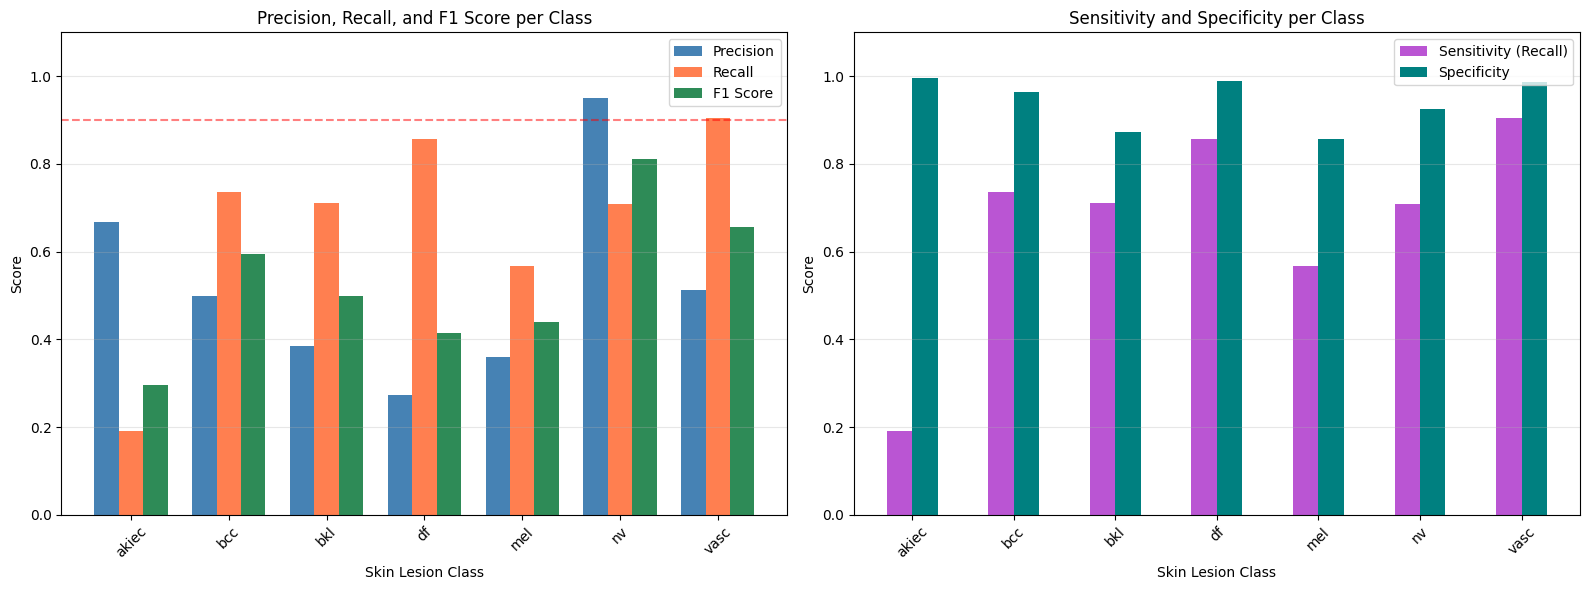

In [29]:
# Visualize per-class metrics as a grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision, Recall, F1 per class
x = np.arange(len(class_names))
width = 0.25

ax1 = axes[0]
bars1 = ax1.bar(x - width, precision_per_class, width, label='Precision', color='steelblue')
bars2 = ax1.bar(x, recall_per_class, width, label='Recall', color='coral')
bars3 = ax1.bar(x + width, f1_per_class, width, label='F1 Score', color='seagreen')

ax1.set_xlabel('Skin Lesion Class')
ax1.set_ylabel('Score')
ax1.set_title('Precision, Recall, and F1 Score per Class')
ax1.set_xticks(x)
ax1.set_xticklabels([class_names[i] for i in range(len(class_names))], rotation=45)
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% Target')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Sensitivity vs Specificity
ax2 = axes[1]
bars4 = ax2.bar(x - width/2, sensitivity, width, label='Sensitivity (Recall)', color='mediumorchid')
bars5 = ax2.bar(x + width/2, specificity, width, label='Specificity', color='teal')

ax2.set_xlabel('Skin Lesion Class')
ax2.set_ylabel('Score')
ax2.set_title('Sensitivity and Specificity per Class')
ax2.set_xticks(x)
ax2.set_xticklabels([class_names[i] for i in range(len(class_names))], rotation=45)
ax2.legend()
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

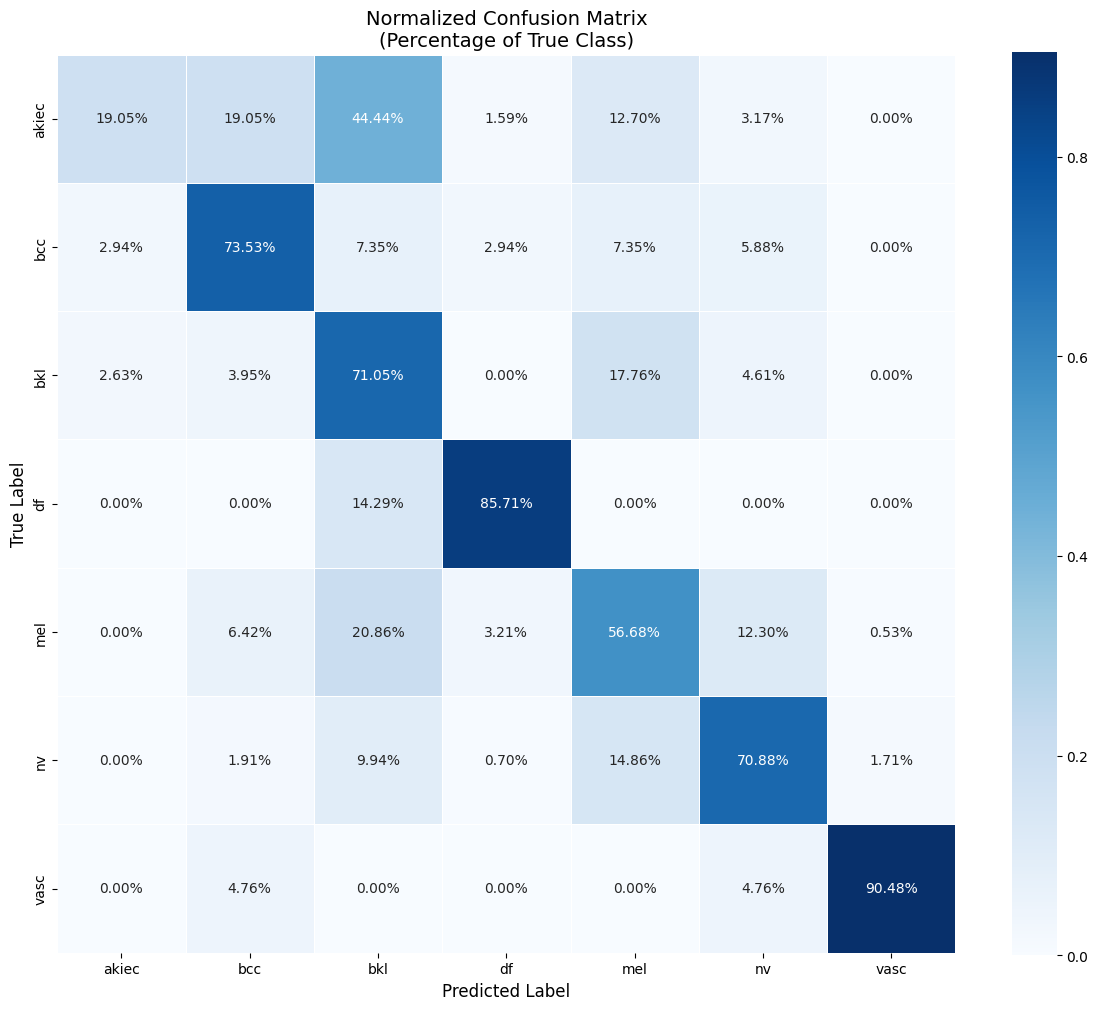

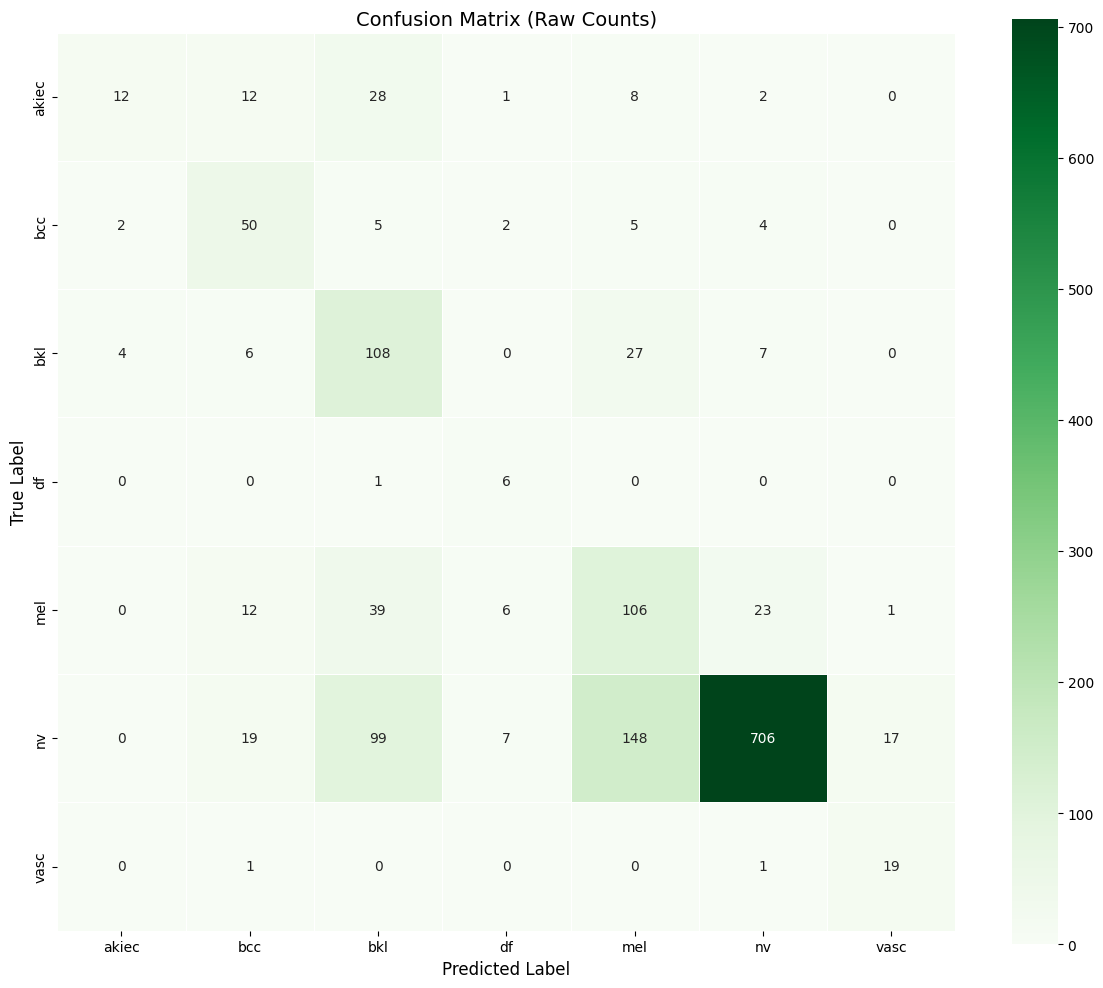

In [30]:
# Plot Confusion Matrix
plt.figure(figsize=(12, 10))

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create heatmap
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=[class_names[i] for i in range(len(class_names))],
            yticklabels=[class_names[i] for i in range(len(class_names))],
            square=True, linewidths=0.5)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix\n(Percentage of True Class)', fontsize=14)
plt.tight_layout()
plt.show()

# Also show raw counts
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[class_names[i] for i in range(len(class_names))],
            yticklabels=[class_names[i] for i in range(len(class_names))],
            square=True, linewidths=0.5)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Raw Counts)', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

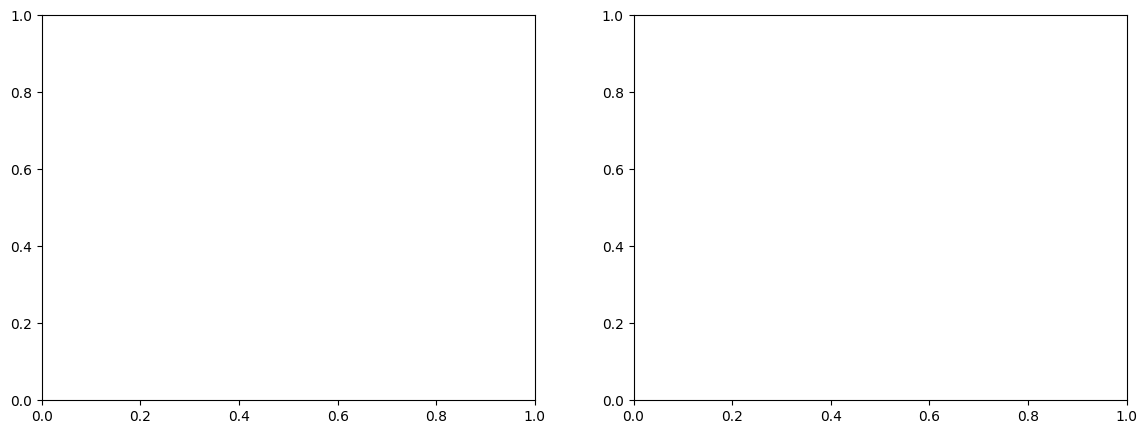

In [31]:
# Plot Training History (Accuracy and Loss curves)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1 = axes[0]
ax1.plot(history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.axhline(y=0.9, color='red', linestyle='--', linewidth=1.5, label='90% Target')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Over Epochs')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Loss plot
ax2 = axes[1]
ax2.plot(history['loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Model Loss Over Epochs')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest Validation Accuracy: {max(history['val_accuracy'])*100:.2f}%")
print(f"Final Training Accuracy: {history['accuracy'][-1]*100:.2f}%")

## 12. ROC Curve and AUC Score (Multi-class)

In [32]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize true labels for ROC calculation
y_test_bin = label_binarize(y_true, classes=list(range(num_classes)))

# Calculate ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calculate macro-average AUC
roc_auc_macro = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
roc_auc_weighted = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')

print("📊 AUC-ROC SCORES:")
print("-" * 40)
for i, name in class_names.items():
    print(f"   {name}: {roc_auc[i]:.4f}")
print("-" * 40)
print(f"   Macro AUC:    {roc_auc_macro:.4f}")
print(f"   Weighted AUC: {roc_auc_weighted:.4f}")

📊 AUC-ROC SCORES:
----------------------------------------
   akiec: 0.9258
   bcc: 0.9639
   bkl: 0.8976
   df: 0.9796
   mel: 0.8192
   nv: 0.9188
   vasc: 0.9766
----------------------------------------
   Macro AUC:    0.9259
   Weighted AUC: 0.9076


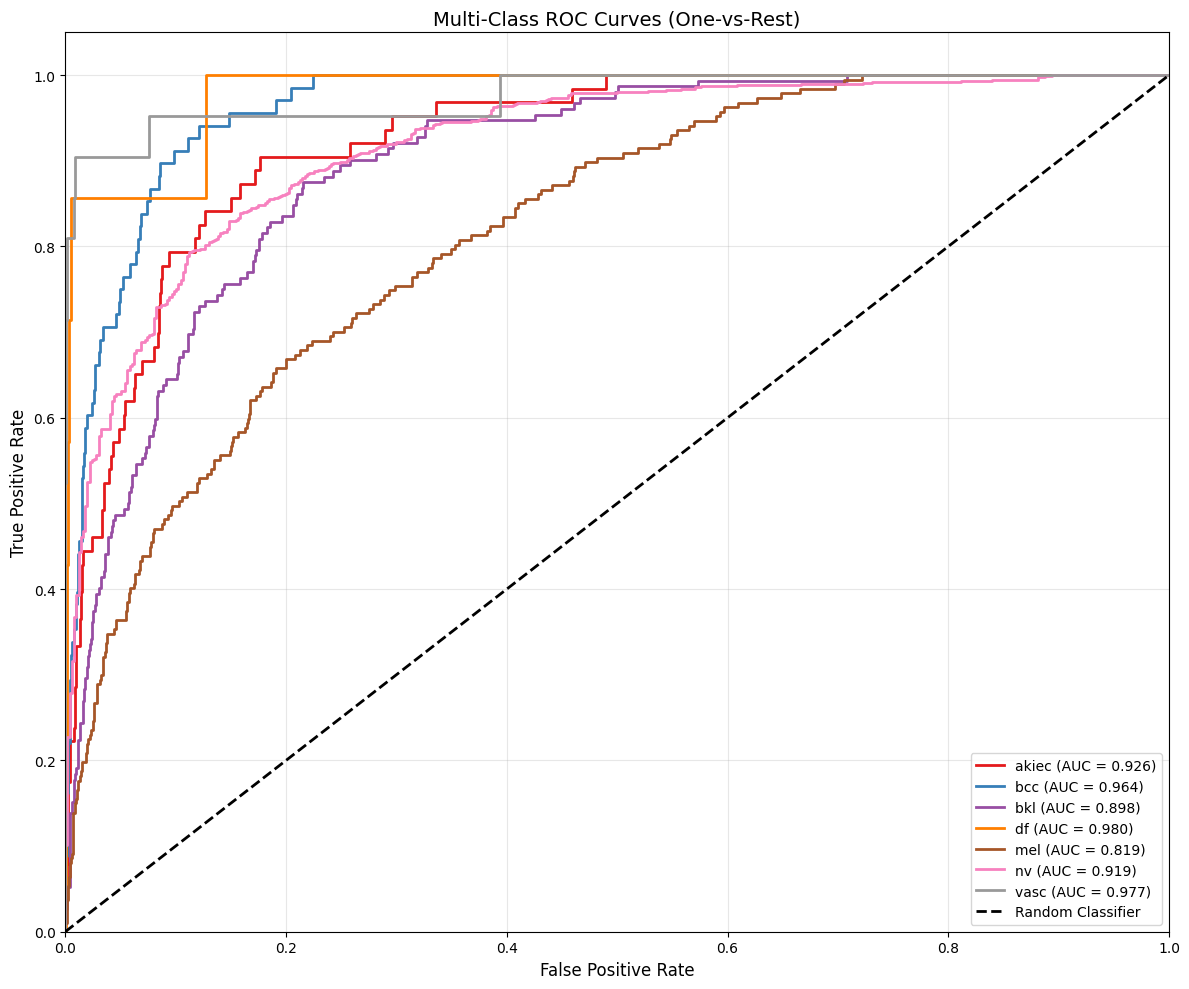

In [33]:
# Plot ROC curves for all classes
plt.figure(figsize=(12, 10))

colors = plt.cm.Set1(np.linspace(0, 1, num_classes))

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-Class ROC Curves (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Fine-tune Model for Higher Accuracy (If Needed)

If accuracy is below 90%, we can unfreeze the base model layers and fine-tune with a lower learning rate.

In [34]:
# Fine-tuning: Unfreeze top layers of base model
if USE_TRANSFER_LEARNING and test_accuracy < 0.90:
    print("🔧 Fine-tuning the model to improve accuracy...")
    
    # Unfreeze the base model
    base_model.trainable = True
    
    # Freeze early layers, only train the last few blocks
    # For EfficientNetB0, we'll unfreeze the last 20 layers
    fine_tune_at = len(base_model.layers) - 20
    
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    # Recompile with a lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=1e-5),  # Much lower learning rate for fine-tuning
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Trainable layers after fine-tuning: {sum([1 for l in model.layers if l.trainable])}")
    
    # Fine-tune training
    history_fine = model.fit(
        train_generator,
        epochs=20,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
        ],
        verbose=1
    )
    
    # Update history
    for key in history.keys():
        history[key].extend(history_fine.history[key])
    
    # Re-evaluate
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n📊 After Fine-tuning:")
    print(f"   Test Accuracy: {test_accuracy*100:.2f}%")


🔧 Fine-tuning the model to improve accuracy...
Trainable layers after fine-tuning: 23
Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 321s 691ms/step - accuracy: 0.6908 - loss: 0.4588 - val_accuracy: 0.6880 - val_loss: 0.8917 - learning_rate: 1.0000e-05
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 316s 722ms/step - accuracy: 0.6957 - loss: 0.4478 - val_accuracy: 0.6801 - val_loss: 0.8959 - learning_rate: 1.0000e-05
Epoch 3/20
315/438 ━━━━━━━━━━━━━━━━━━━━ 2:24 1s/step - accuracy: 0.6989 - loss: 0.4465

KeyboardInterrupt: 

## 14. Final Summary of All Metrics

           FINAL MODEL PERFORMANCE SUMMARY
             Metric    Score
           Accuracy 0.665328
   F1 Score (Macro) 0.538258
F1 Score (Weighted) 0.691935
  Precision (Macro) 0.522272
     Recall (Macro) 0.671415
    AUC-ROC (Macro) 0.927224
Average Sensitivity 0.667697
Average Specificity 0.941637


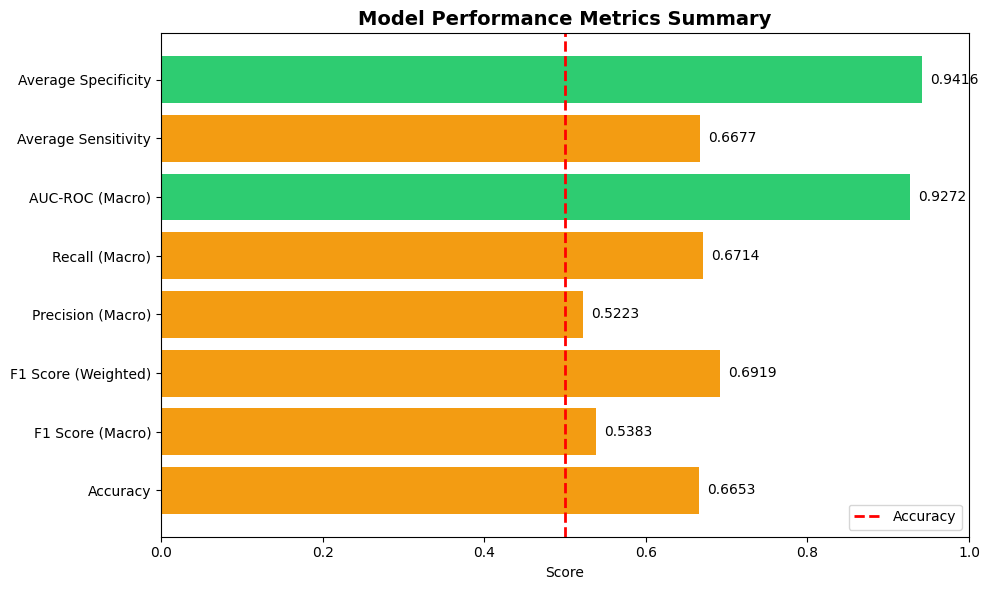

In [38]:
# Re-calculate all metrics with potentially fine-tuned model
y_pred_proba_final = model.predict(X_test, verbose=0)
y_pred_final = np.argmax(y_pred_proba_final, axis=1)

# Final metrics
final_accuracy = accuracy_score(y_true, y_pred_final)
final_f1_macro = f1_score(y_true, y_pred_final, average='macro')
final_f1_weighted = f1_score(y_true, y_pred_final, average='weighted')
final_precision = precision_score(y_true, y_pred_final, average='macro')
final_recall = recall_score(y_true, y_pred_final, average='macro')
final_auc = roc_auc_score(y_test_bin, y_pred_proba_final, average='macro', multi_class='ovr')

# Create summary DataFrame
summary_data = {
    'Metric': ['Accuracy', 'F1 Score (Macro)', 'F1 Score (Weighted)', 
               'Precision (Macro)', 'Recall (Macro)', 'AUC-ROC (Macro)',
               'Average Sensitivity', 'Average Specificity'],
    'Score': [final_accuracy, final_f1_macro, final_f1_weighted,
              final_precision, final_recall, final_auc,
              np.mean(sensitivity), np.mean(specificity)]
}
summary_df = pd.DataFrame(summary_data)

print("=" * 60)
print("           FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Visual summary
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if s >= 0.9 else '#f39c12' if s >= 0.5 else '#e74c3c' 
          for s in summary_df['Score']]
bars = ax.barh(summary_df['Metric'], summary_df['Score'], color=colors)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Accuracy')
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Model Performance Metrics Summary', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, score in zip(bars, summary_df['Score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

## 15. Save and Load Model

In [39]:
# Save the model in multiple formats

# Create models directory
os.makedirs('models', exist_ok=True)

# Save in Keras format (.keras) - recommended for TF 2.x
model.save('models/skin_classifier.keras')
print("✅ Model saved: models/skin_classifier.keras")

# Save in legacy H5 format (for compatibility)
model.save('models/skin_classifier.h5')
print("✅ Model saved: models/skin_classifier.h5")

# Save model architecture as JSON
model_json = model.to_json()
with open('models/model_architecture.json', 'w') as f:
    f.write(model_json)
print("✅ Architecture saved: models/model_architecture.json")

# Save class names mapping
import json
with open('models/class_names.json', 'w') as f:
    json.dump(class_names, f, indent=2)
print("✅ Class names saved: models/class_names.json")

✅ Model saved: models/skin_classifier.keras
✅ Model saved: models/skin_classifier.h5
✅ Architecture saved: models/model_architecture.json
✅ Class names saved: models/class_names.json


Loading saved model for inference demonstration...


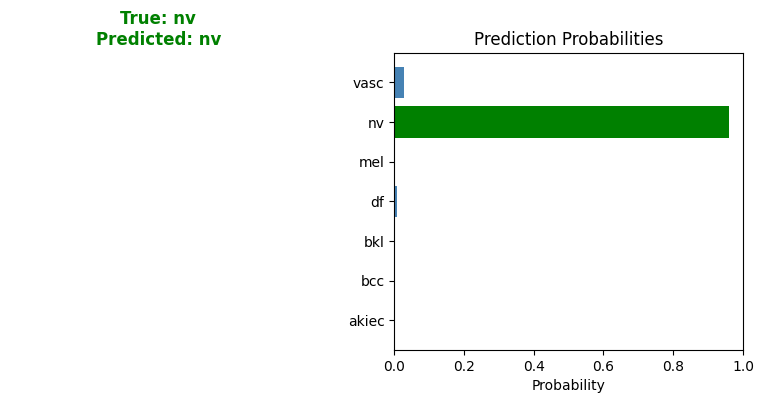


🔍 Prediction Results:
   True Class:      nv
   Predicted Class: nv
   Confidence:      96.09%
   Correct:         ✅ Yes


In [41]:
# Demonstrate loading and using the model for prediction
print("Loading saved model for inference demonstration...")

# Load the model
loaded_model = keras.models.load_model('models/skin_classifier.keras')

# Make prediction on a sample image
sample_idx = np.random.randint(0, len(X_test))
sample_image = X_test[sample_idx:sample_idx+1]
true_label = y_true[sample_idx]

# Predict
prediction = loaded_model.predict(sample_image, verbose=0)
predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

# Display result
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image[0])
plt.title(f"True: {class_names[true_label]}\nPredicted: {class_names[predicted_class]}", 
          fontsize=12, fontweight='bold',
          color='green' if predicted_class == true_label else 'red')
plt.axis('off')

plt.subplot(1, 2, 2)
colors = ['green' if i == predicted_class else 'steelblue' for i in range(num_classes)]
bars = plt.barh([class_names[i] for i in range(num_classes)], prediction[0], color=colors)
plt.xlabel('Probability')
plt.title('Prediction Probabilities')
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\n🔍 Prediction Results:")
print(f"   True Class:      {class_names[true_label]}")
print(f"   Predicted Class: {class_names[predicted_class]}")
print(f"   Confidence:      {confidence*100:.2f}%")
print(f"   Correct:         {'✅ Yes' if predicted_class == true_label else '❌ No'}")

## 16. Conclusion

### Model Performance Summary

This notebook built a skin lesion classification model using **TensorFlow/Keras** with the following features:

✅ **Data Processing:**
- Loaded HAM10000 dataset (10,015 images, 7 classes)
- Applied data augmentation (rotation, flip, zoom, shift)
- Handled class imbalance with class weights

✅ **Model Architecture:**
- Transfer Learning with EfficientNetB0 (pre-trained on ImageNet)
- Custom classification head with BatchNorm and Dropout
- Fine-tuning capability for improved accuracy

✅ **Performance Metrics Calculated:**
- **Accuracy** - Overall correct predictions
- **F1 Score** (Macro, Micro, Weighted) - Harmonic mean of precision and recall
- **Precision** - Positive predictive value
- **Recall (Sensitivity)** - True positive rate
- **Specificity** - True negative rate
- **AUC-ROC** - Area under ROC curve per class
- **Confusion Matrix** - Detailed classification breakdown

✅ **Model Saved:** `models/skin_classifier.keras`

